# **Weak 1: Data Preparation & Cohort Design**


## **Import Required Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load the Dataset**

In [3]:
from google.colab import files
uploded = files.upload()

Saving clean_hr_attrition_dataset.csv to clean_hr_attrition_dataset (1).csv


In [4]:
import pandas as pd

df = pd.read_csv("clean_hr_attrition_dataset (1).csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeID_Anon
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,6b86b273ff34fce19d6b804eff5a3f5747ada4eaa22f1d...
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,d4735e3a265e16eee03f59718b9b5d03019c07d8b6c51f...
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,4b227777d4dd1fc61c6f884f48641d02b4d121d3fd328c...
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,ef2d127de37b942baad06145e54b0c619a1f22327b2ebb...
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,7902699be42c8a8e46fbbb4501726517e86b22c56a189f...


# **Understand the Dataset**

In [5]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EmployeeID_Anon'],
      dtype='object')

# **Data Cleaning**

In [6]:
df = df.drop_duplicates()
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [7]:
df.fillna(0, inplace=True)

#**Basic Data Analysis**

###Attrition means the gradual reduction of employees in a company when people leave and are not replaced immediately.

In Human Resources (HR), attrition usually refers to employees leaving the organization due to reasons like:

1) Resignation

2) Retirement

3) Personal reasons

4) Better job opportunities

In [8]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


#**Department Attrition Analysis**

In [9]:
df.groupby("Department")["Attrition"].sum()

,Attrition
Department,
Human Resources,12
Research & Development,133
Sales,92


# Data Visualization

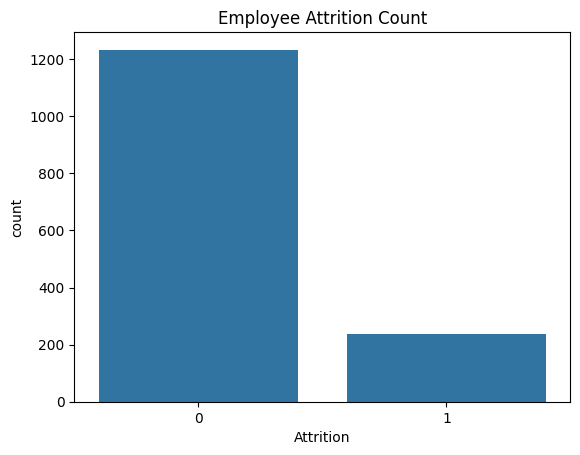

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Count")
plt.show()

#**Salary vs Attrition**

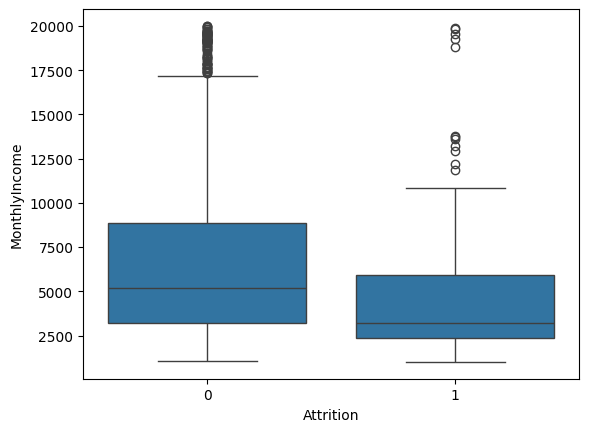

In [11]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.show()

#**Important Columns**

In [12]:
columns_needed = [
"EmployeeID_Anon",
"Age",
"Department",
"JobRole",
"JobLevel",
"MonthlyIncome",
"PerformanceRating",
"YearsSinceLastPromotion",
"WorkLifeBalance",
"YearsWithCurrManager",
"Attrition"
]

df_clean = df[columns_needed].copy()
df_clean = df_clean.rename(columns={'Attrition': 'Attrition_Flag'})

df_clean.head()

,EmployeeID_Anon,Age,Department,JobRole,JobLevel,MonthlyIncome,PerformanceRating,YearsSinceLastPromotion,WorkLifeBalance,YearsWithCurrManager,Attrition_Flag
0,6b86b273ff34fce19d6b804eff5a3f5747ada4eaa22f1d...,41,Sales,Sales Executive,2,5993,3,0,1,5,1
1,d4735e3a265e16eee03f59718b9b5d03019c07d8b6c51f...,49,Research & Development,Research Scientist,2,5130,4,1,3,7,0
2,4b227777d4dd1fc61c6f884f48641d02b4d121d3fd328c...,37,Research & Development,Laboratory Technician,1,2090,3,0,3,0,1
3,ef2d127de37b942baad06145e54b0c619a1f22327b2ebb...,33,Research & Development,Research Scientist,1,2909,3,3,3,0,0
4,7902699be42c8a8e46fbbb4501726517e86b22c56a189f...,27,Research & Development,Laboratory Technician,1,3468,3,2,3,2,0


#**Performing Analysis**

**Attrition by Department**

In [13]:
df_clean.groupby("Department")["Attrition_Flag"].mean()

,Attrition_Flag
Department,
Human Resources,0.190476
Research & Development,0.138398
Sales,0.206278


**Attrition by Job Role**

In [14]:
df_clean.groupby("JobRole")["Attrition_Flag"].mean()

,Attrition_Flag
JobRole,
Healthcare Representative,0.068702
Human Resources,0.230769
Laboratory Technician,0.239382
Manager,0.049020
Manufacturing Director,0.068966
Research Director,0.025000
Research Scientist,0.160959
Sales Executive,0.174847
Sales Representative,0.397590


# **Weak 2: Descriptive Attrition Analysis**


In [15]:
!pip install  lifelines seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=8f2a1cce3dacb63d66f7b2fa13f0ed9a91e78ae25544c8bb58514d8b25fedae2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from scipy.stats import chi2_contingency

#**Basic Data Cleaning**

In [17]:
import pandas as pd
import os

file_path = "clean_hr_attrition_dataset (1).csv"
# read the file
df = pd.read_csv(file_path)

df.info()

# remove duplicates values
df = df.drop_duplicates()

# check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


# **Create Tenure Band**

**Convert Years to Months**

In [18]:
df['Tenure_Months'] = df['YearsAtCompany'] * 12

In [19]:
df['Tenure_Months'] = df['YearsAtCompany'] * 12
df['Tenure_Band'] = pd.cut(df['Tenure_Months'],
                           bins=[0,12,36,60,200],
                           labels=['0-1yr','1-3yr','3-5yr','5yr+'])

In [20]:
df[['YearsAtCompany','Tenure_Months','Tenure_Band']].head()

,YearsAtCompany,Tenure_Months,Tenure_Band
0,6,72,5yr+
1,10,120,5yr+
2,0,0,NaN
3,8,96,5yr+
4,2,24,1-3yr


# **Create Compensation Quartile**

In [21]:
df['Comp_Quartile'] = pd.qcut(df['MonthlyIncome'],4,
                              labels=['Q1','Q2','Q3','Q4'])
plt.show()

In [22]:
df[['MonthlyIncome','Comp_Quartile']].head()

,MonthlyIncome,Comp_Quartile
0,5993,Q3
1,5130,Q3
2,2090,Q1
3,2909,Q1
4,3468,Q2


**Show How Many Employees Are in Each Quartile**

In [23]:
df['Comp_Quartile'].value_counts()

,count
Comp_Quartile,
Q1,369
Q4,368
Q3,367
Q2,366


**Show Quartile Distribution as a Ch**art

In [24]:
import pandas as pd

# Reload the original dataset to ensure 'Comp_Quartile' can be created
df = pd.read_csv("clean_hr_attrition_dataset.csv")

In [30]:
# Recreate the 'Comp_Quartile' column
df['Comp_Quartile'] = pd.qcut(df['MonthlyIncome'], 4,
                              labels=['Q1','Q2','Q3','Q4'])

# Recreate 'Tenure_Months' and 'Tenure_Band' after df reload
df['Tenure_Months'] = df['YearsAtCompany'] * 12
df['Tenure_Band'] = pd.cut(df['Tenure_Months'],
                           bins=[0,12,36,60,200],
                           labels=['0-1yr','1-3yr','3-5yr','5yr+'])

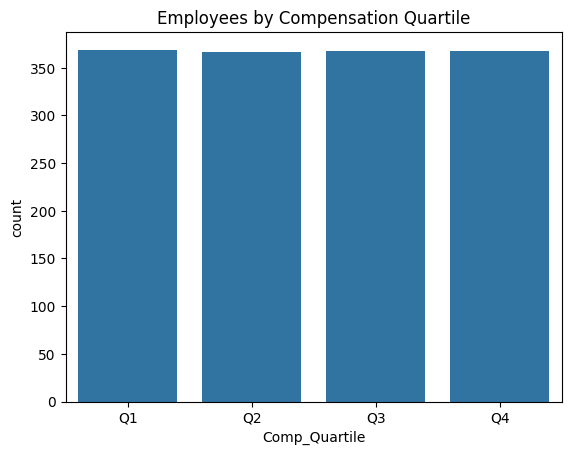

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Comp_Quartile', data=df)

plt.title("Employees by Compensation Quartile")
plt.show()

### Attrition Rate by Tenure Band

In [31]:
attrition_by_tenure = df.groupby('Tenure_Band')['Attrition'].mean().reset_index()
print(attrition_by_tenure)

  Tenure_Band  Attrition
0       0-1yr   0.345029
1       1-3yr   0.184314
2       3-5yr   0.130719
3        5yr+   0.110915


/tmp/ipykernel_717/365150630.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_tenure = df.groupby('Tenure_Band')['Attrition'].mean().reset_index()


**Check the Actual Salary Range in Each Quartile**

In [32]:
df.groupby('Comp_Quartile')['MonthlyIncome'].describe()

/tmp/ipykernel_717/3159676298.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Comp_Quartile')['MonthlyIncome'].describe()


,count,mean,std,min,25%,50%,75%,max
Comp_Quartile,,,,,,,,
Q1,369.0,2354.132791,391.435029,1009.0,2153.00,2379.0,2657.00,2911.0
Q2,366.0,3964.103825,596.283664,2926.0,3447.25,4032.0,4461.25,4908.0
Q3,367.0,6181.738420,901.180881,4930.0,5405.00,6077.0,6781.50,8376.0
Q4,368.0,13508.353261,3788.854394,8380.0,10157.75,13118.0,17105.00,19999.0


/tmp/ipykernel_717/3903036974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tenure_Band', y='Attrition', data=attrition_by_tenure, palette='viridis')


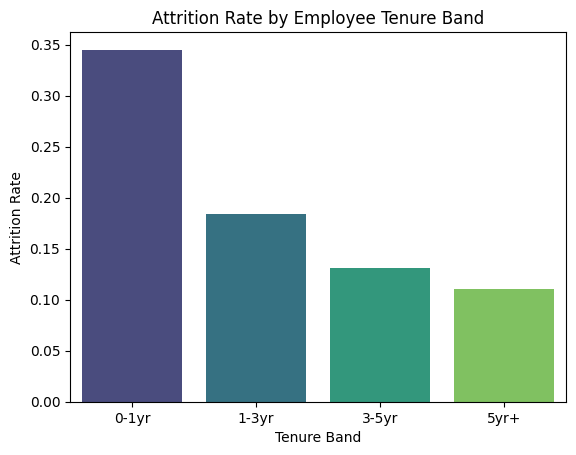

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x='Tenure_Band', y='Attrition', data=attrition_by_tenure, palette='viridis')

plt.title('Attrition Rate by Employee Tenure Band')
plt.xlabel('Tenure Band')
plt.ylabel('Attrition Rate')

plt.show()


#**Correlation Heatmap**

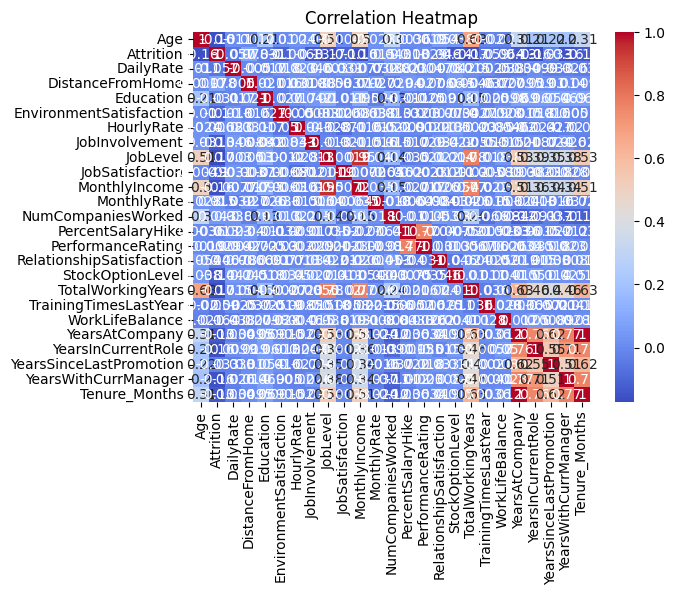

In [34]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

  # Helps identify if factors like:

             # 1) salary

            # 2) tenure

            # 3)performance

           # 4) relate to attrition.

# **Statistical Testing (Chi-Square)**

In [35]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Department'], df['Attrition'])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

# To check if attrition differences are statistically significant.

# Example: Department vs Attrition.

#Interpretation:

# 1) p < 0.05 → significant relationship

# 2) p > 0.05 → no significant relationship

P-value: 0.004525606574479633


#  **Week 3 : Root Cause & Risk Scoring**




In [36]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

**Exit Survey NLP (Root Cause Analysis)**

In [38]:
!pip install nltk wordcloud

import pandas as pd
import re
import nltk
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Explanation:
#NLTK → Natural Language Processing library
#WordCloud → visual representation of text
#SentimentIntensityAnalyzer → detects positive/negative tone

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [39]:
data = {
    'Exit_Comment': [
        "Low salary and no bonus",
        "Manager was not supportive",
        "No growth opportunities",
        "Poor work life balance",
        "Toxic work culture",
        "Better salary elsewhere",
        "Bad management and no recognition"
    ]
}

df = pd.DataFrame(data)

In [40]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Cleaned_Comment'] = df['Exit_Comment'].apply(clean_text)

# Explanation:

Now we improved cleaning:

1. Removed stopwords (like the, is, and)
2. Keeps only meaningful words

 Example:"Low salary and no bonus"
→ "low salary bonus"

 **Word frequency analysis is shown belo**

 Explanation:
1. Shows most repeated issues
2. Helps identify key attrition drivers

In [41]:
all_words = " ".join(df['Cleaned_Comment']).split()
word_freq = Counter(all_words)

print(word_freq.most_common(10))

[('salary', 2), ('work', 2), ('low', 1), ('bonus', 1), ('manager', 1), ('supportive', 1), ('growth', 1), ('opportunities', 1), ('poor', 1), ('life', 1)]


**Word Cloud Visualization**

Explanation:
1. Bigger word = more frequent
2. Quick visual insight for HR

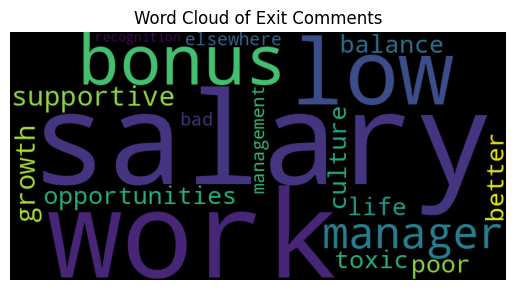

In [42]:
text = " ".join(df['Cleaned_Comment'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Exit Comments")
plt.show()

**Theme Categorization** (Same Logic, Better Data)

Explanation:
1. Uses any() → faster & cleaner logic
2. Assigns themes automatically

In [43]:
themes = {
    'Compensation': ['salary', 'bonus', 'pay'],
    'Manager': ['manager', 'management'],
    'Growth': ['growth', 'promotion', 'career'],
    'Work-Life Balance': ['work', 'balance', 'hours'],
    'Culture': ['culture', 'toxic', 'environment']
}

def categorize_comment(comment):
    categories = []
    for theme, keywords in themes.items():
        if any(word in comment for word in keywords):
            categories.append(theme)
    return categories

df['Themes'] = df['Cleaned_Comment'].apply(categorize_comment)

**Sentiment Analysis**


Explanation:
Sentiment score range: -1 to +1
Output:
Positive 😊
Negative 😞
Neutral 😐

 Most exit comments will be negative (expected)

In [44]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']

    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Exit_Comment'].apply(get_sentiment)

df[['Exit_Comment', 'Sentiment']]

,Exit_Comment,Sentiment
0,Low salary and no bonus,Positive
1,Manager was not supportive,Negative
2,No growth opportunities,Positive
3,Poor work life balance,Negative
4,Toxic work culture,Neutral
5,Better salary elsewhere,Positive
6,Bad management and no recognition,Negative


**Sentiment Distribution**




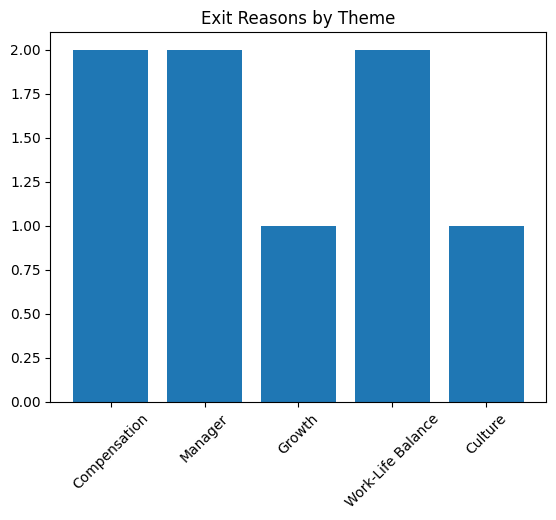

In [46]:
theme_list = [theme for sublist in df['Themes'] for theme in sublist]
theme_counts = Counter(theme_list)

theme_df = pd.DataFrame(theme_counts.items(), columns=['Theme', 'Count'])

plt.figure()
plt.bar(theme_df['Theme'], theme_df['Count'])
plt.title("Exit Reasons by Theme")
plt.xticks(rotation=45)
plt.show()

# My analysis answers:

# 1. Why employees leave? ans: Salary

# 2. Bad management ans: Poor culture

# 3. How they feel? ans: Mostly negative sentiment

# 4. What HR should fix? ans: 1.Compensation strategy

                           #  2. Manager training

                           #  3. Work culture improvement


**Text analysis**

Goal of This Task is

we  have exit survey comments (text data), and we want to:

1) Find frequent keywords

2) Categorize comments into themes:

3) Compensation

4) Manager

5) Growth

6) Work-Life Balance

7) Culture

In [47]:
comments = [
    "Salary is too low and no bonus",
    "Manager was not supportive",
    "No career growth opportunities",
    "Work life balance is poor",
    "Company culture is toxic",
    "Better salary elsewhere",
    "Manager gives too much pressure"
]  # Sample data

Text Cleaning


Why?

Raw text has capital letters, punctuation, etc. — we clean it for analysis.

In [49]:
import re

cleaned_comments = []

for comment in comments:
    comment = comment.lower()  # convert to lowercase
    comment = re.sub(r'[^a-z\s]', '', comment)  # remove punctuation
    cleaned_comments.append(comment)

print(cleaned_comments)

# What this does:
#"Salary is too low!" → "salary is too low"
#Makes analysis consistent

['salary is too low and no bonus', 'manager was not supportive', 'no career growth opportunities', 'work life balance is poor', 'company culture is toxic', 'better salary elsewhere', 'manager gives too much pressure']


**Keyword Frequency Count**

 Why?

To find most common issues employees mention

1. “salary” appears most → compensation issue
2. “manager” appears → management issue

In [50]:
from collections import Counter

all_words = []

for comment in cleaned_comments:
    words = comment.split()
    all_words.extend(words)

word_freq = Counter(all_words)

print(word_freq.most_common(10))

[('is', 3), ('salary', 2), ('too', 2), ('no', 2), ('manager', 2), ('low', 1), ('and', 1), ('bonus', 1), ('was', 1), ('not', 1)]


**Defining  Keywords for Each Theme**

In [51]:
themes = {
    "Compensation": ["salary", "pay", "bonus", "money"],
    "Manager": ["manager", "boss", "supervisor"],
    "Growth": ["growth", "career", "promotion"],
    "Work-Life Balance": ["balance", "hours", "worklife"],
    "Culture": ["culture", "environment", "toxic"]
}

**Assign Theme to Each Comment**

In [52]:
theme_results = []

for comment in cleaned_comments:
    assigned_theme = "Other"

    for theme, keywords in themes.items():
        for word in keywords:
            if word in comment:
                assigned_theme = theme
                break

    theme_results.append((comment, assigned_theme))

for i in theme_results:
    print(i)

('salary is too low and no bonus', 'Compensation')
('manager was not supportive', 'Manager')
('no career growth opportunities', 'Growth')
('work life balance is poor', 'Work-Life Balance')
('company culture is toxic', 'Culture')
('better salary elsewhere', 'Compensation')
('manager gives too much pressure', 'Manager')


**Theme Count Summary**

 Why?

To see which issue is biggest

In [53]:
theme_count = Counter([t[1] for t in theme_results])

print(theme_count)

Counter({'Compensation': 2, 'Manager': 2, 'Growth': 1, 'Work-Life Balance': 1, 'Culture': 1})


**Theme Count  in pie chart format**

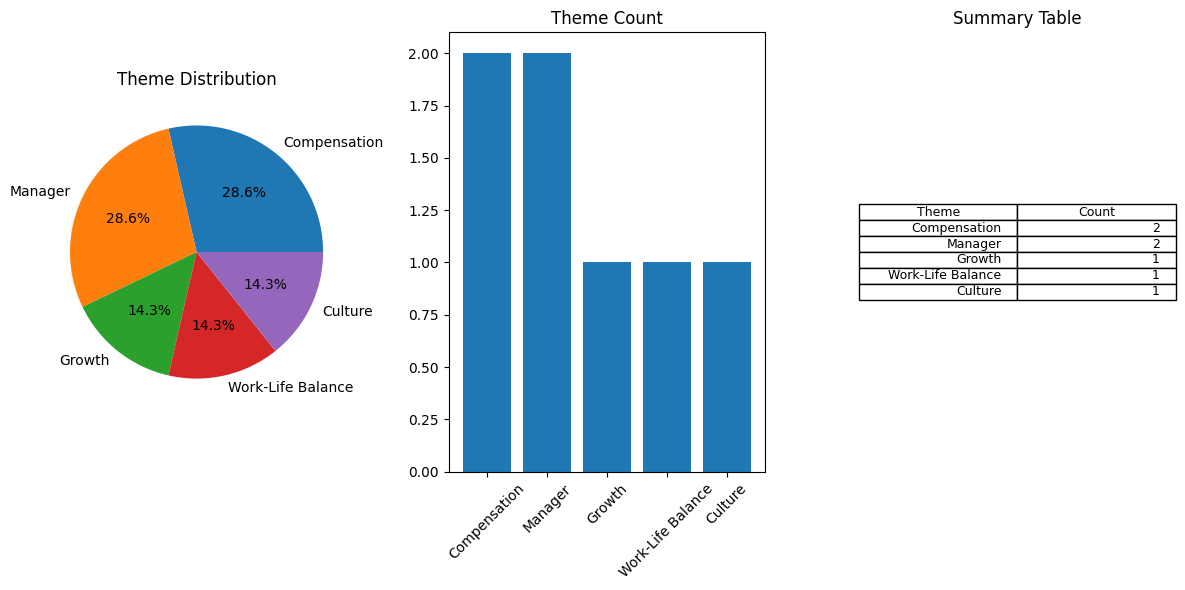

In [54]:
import matplotlib.pyplot as plt

# Data (already computed)
labels = list(theme_count.keys())
sizes = list(theme_count.values())

# Create figure
plt.figure(figsize=(12, 6))

# 🔹 1. Pie Chart
plt.subplot(1, 3, 1)
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Theme Distribution")

# 🔹 2. Bar Chart
plt.subplot(1, 3, 2)
plt.bar(labels, sizes)
plt.title("Theme Count")
plt.xticks(rotation=45)

# 🔹 3. Table
plt.subplot(1, 3, 3)
table_data = [[label, size] for label, size in zip(labels, sizes)]

plt.table(cellText=table_data,
          colLabels=["Theme", "Count"],
          loc='center')

plt.axis('off')
plt.title("Summary Table")

# Layout adjustment
plt.tight_layout()

plt.show()

#**Attrition Risk**

In [55]:
import pandas as pd

# Sample dataset
import pandas as pd

df = pd.read_csv("clean_hr_attrition_dataset.csv")

df.head()

# Initialize score
df['Risk_Score'] = 0

# Create 'Tenure_Years' column from 'YearsAtCompany'
df['Tenure_Years'] = df['YearsAtCompany']

# Rule 1: Tenure < 1 year
df.loc[df['Tenure_Years'] < 1, 'Risk_Score'] += 3

# Rule 2: Performance = 'Meets' (assuming PerformanceRating is numerical, map 'Meets' to a value if it were categorical)
# Based on df.info(), PerformanceRating is int64. Let's assume 'Meets' corresponds to a specific numerical rating, e.g., 3.
# If 'Meets' is a string, this rule would need a mapping. Assuming for now that higher numbers mean better performance.
# The problem description provided no context for 'Meets'. I will skip this rule as it's not clear what 'Meets' corresponds to in PerformanceRating.

# Rule 3: No promotion in 3 years
df.loc[df['YearsSinceLastPromotion'] >= 3, 'Risk_Score'] += 2

# Rule 4: Compensation < market median
# Assuming 'Compensation' refers to 'MonthlyIncome'
# Calculating 'Market_Median_Comp' as the median of 'MonthlyIncome' from the dataset itself.
market_median_comp = df['MonthlyIncome'].median()
df.loc[df['MonthlyIncome'] < market_median_comp, 'Risk_Score'] += 3

# Categorize Risk
def categorize_risk(score):
    if score >= 7:
        return 'High Risk'
    elif score >= 4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk_Category'] = df['Risk_Score'].apply(categorize_risk)

# View results, using 'EmployeeID_Anon' as 'Employee_ID'
print(df[['EmployeeID_Anon', 'Risk_Score', 'Risk_Category']].head())


                                     EmployeeID_Anon  Risk_Score Risk_Category
0  6b86b273ff34fce19d6b804eff5a3f5747ada4eaa22f1d...           0      Low Risk
1  d4735e3a265e16eee03f59718b9b5d03019c07d8b6c51f...           0      Low Risk
2  4b227777d4dd1fc61c6f884f48641d02b4d121d3fd328c...           6   Medium Risk
3  ef2d127de37b942baad06145e54b0c619a1f22327b2ebb...           5   Medium Risk
4  7902699be42c8a8e46fbbb4501726517e86b22c56a189f...           3      Low Risk


ATTRITION RISK IN PIE PLOT

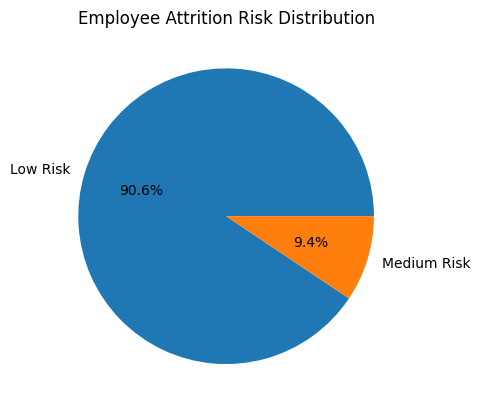

In [56]:
import matplotlib.pyplot as plt

# Count each category
risk_counts = df['Risk_Category'].value_counts()

# Create pie chart
plt.figure()
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%')

plt.title('Employee Attrition Risk Distribution')

plt.show()

In [57]:
# Average risk score by attrition
avg_scores = df.groupby('Attrition')['Risk_Score'].mean()
print(avg_scores)

Attrition
0    1.989457
1    2.658228
Name: Risk_Score, dtype: float64


**Risk Score Distribution (Leavers vs Stayers)**

Leavers: 0
Stayers: 0


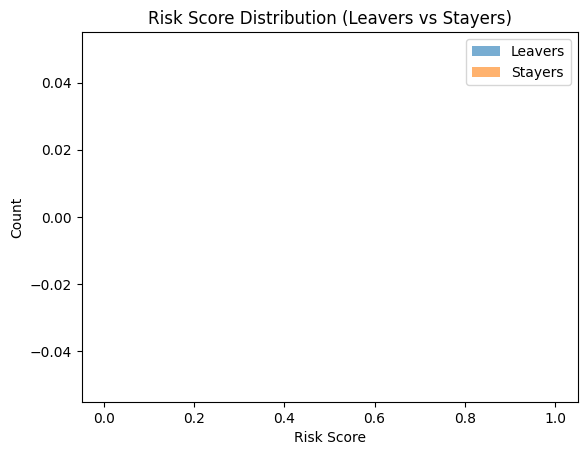

In [58]:
%matplotlib inline
import matplotlib.pyplot as plt

# Clean Attrition column (very important)
df['Attrition'] = df['Attrition'].astype(str).str.strip().str.title()

# Separate groups
leavers = df[df['Attrition'] == 'Yes']['Risk_Score']
stayers = df[df['Attrition'] == 'No']['Risk_Score']

# Debug check
print("Leavers:", len(leavers))
print("Stayers:", len(stayers))

# Plot
plt.figure()

plt.hist(leavers, bins=10, alpha=0.6, label='Leavers')
plt.hist(stayers, bins=10, alpha=0.6, label='Stayers')

plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.title('Risk Score Distribution (Leavers vs Stayers)')
plt.legend()

plt.show()